# $n^*$ estimation works

Show that studies of size $n^*$ are (very often) externally valid, for various kernels.

In [47]:
import numpy as np
import pandas as pd

from itertools import product
from pathlib import Path
from tqdm.auto import tqdm

from genexpy.kernels import rankings as kru
from genexpy import random as du, UniformDistribution

figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True, parents=True)
outputs_dir = Path("outputs")
outputs_dir.mkdir(exist_ok=True, parents=True)

seed = 1444
nrep = 50
alpha = 0.95
delta = 0.05
load_precomputed = False

# Distributions
nas = [8]
distrs = [du.UniformDistribution(na=na, seed=seed*na) for na in nas]

# Sizes of preliminary studies
Ns = [10, 20, 40]

First, for all distributions, kernels, and $N$-s (including $\infty$), let's estimate the distribution of the MMD for various $n \leq N // 2$.

In [48]:
dfmmd = None
if load_precomputed:
    try:
        dfmmd = pd.read_parquet(outputs_dir / "dfmmd.parquet")
    except FileNotFoundError:
        pass
    else:
        print(f"[INFO] Loaded existing results from {outputs_dir / 'dfmmd.parquet'}.")

if dfmmd is None:
    out = []
    tmp_seed = seed
    for disjoint, replace in product([True, False], repeat=2):
        for distr in tqdm(distrs, desc="Distribution", position=0, leave=True):
            na = distr.na

            # Kernels (not instantiated because we need na)
            # kernels = [kru.BordaKernel(idx=0, nu="auto", na=na),
            #            kru.JaccardKernel(t=1),
            #            kru.MallowsKernel(nu="auto", na=na),
            #            ]
            kernels = [kru.MallowsKernel(nu="auto", na=na)]

            for kernel in tqdm(kernels, desc="Kernel", position=1, leave=False):
                tmp_seed += 1

                # Estimations
                for N in Ns:
                    for rep in range(nrep):
                        sample = distr.sample(n=N)
                        tmp_seed += 1

                        tmp = kernel.mmd_distribution_many_n(sample, nmin=2, nmax=N//2, step=1, rep=1000, seed=tmp_seed, disjoint=disjoint, replace=replace, method="embedding", N=N)
                        tmp["rep"] = rep
                        tmp["distr"] = str(distr)
                        tmp["distr_latex"] = distr.latex_str()
                        tmp["na"] = na
                        tmp["disjoint"] = disjoint
                        tmp["replace"] = replace
                        out.append(tmp)

                        tmp_seed += 1

    dfmmd = pd.concat(out, axis=0)
    dfmmd.to_parquet(outputs_dir / f"dfmmd.parquet")


Distribution:   0%|          | 0/1 [00:00<?, ?it/s]

Kernel:   0%|          | 0/1 [00:00<?, ?it/s]

Distribution:   0%|          | 0/1 [00:00<?, ?it/s]

Kernel:   0%|          | 0/1 [00:00<?, ?it/s]

Distribution:   0%|          | 0/1 [00:00<?, ?it/s]

Kernel:   0%|          | 0/1 [00:00<?, ?it/s]

Distribution:   0%|          | 0/1 [00:00<?, ?it/s]

Kernel:   0%|          | 0/1 [00:00<?, ?it/s]

Now we have the distribution of $MMD_n$ for various $n$ and its estimator, the distribution of $\hat{MMD}_n$ for various $N$-s. We can get all the $\alpha$-quantiles we need.
After getting the quantiles, we move on to estimating $n^*$.

In [49]:
groupby_keys = ["distr_latex", "na", "kernel", "N", "rep", "disjoint", "replace"]
alphas = np.linspace(0.49, 0.99, 26)

out = []
for group, tmp in tqdm(list(dfmmd.groupby(groupby_keys))):
    tmp2 = tmp.groupby("n")["mmd"].quantile(alphas, interpolation="higher").rename("q_alpha").reset_index()
    tmp2.rename(columns={"level_1": "alpha"}, inplace=True)

    for key, val in zip(groupby_keys, tuple(group)):
        tmp2[key] = val

    out.append(tmp2)

dfq = pd.concat(out, axis=0)

  0%|          | 0/600 [00:00<?, ?it/s]

In [50]:
dfq.head()

,n,alpha,q_alpha,distr_latex,na,kernel,N,rep,disjoint,replace
0,2,0.49,0.523442,$U_{8}$,8,MallowsKernel(nu=0.03571),10,0,False,False
1,2,0.51,0.531091,$U_{8}$,8,MallowsKernel(nu=0.03571),10,0,False,False
2,2,0.53,0.537442,$U_{8}$,8,MallowsKernel(nu=0.03571),10,0,False,False
3,2,0.55,0.543124,$U_{8}$,8,MallowsKernel(nu=0.03571),10,0,False,False
4,2,0.57,0.553338,$U_{8}$,8,MallowsKernel(nu=0.03571),10,0,False,False


In [51]:
# from genexpy.kernels.base import Kernel
#
# dfnstar = dfq.copy()
# dfnstar.loc[:, "b1"] = -2
# dfnstar.loc[:, "b0"] = np.mean(np.log(dfnstar["n"]) - dfnstar["b1"] * np.log(dfnstar["q_alpha"]))
#
# eps_map = {
#     (k, na): Kernel.from_string(k).get_eps(delta, na=na)
#     for k, na in dfnstar[["kernel", "na"]].drop_duplicates().itertuples(index=False)
# }
# dfnstar.loc[:, "eps"] = [eps_map[(k, na)] for k, na in zip(dfnstar["kernel"], dfnstar["na"])]
# dfnstar.loc[:, "nstar"] = np.exp(dfnstar["b1"] * np.log(dfnstar["eps"]) + dfnstar["b0"])

In [52]:
from genexpy.kernels.base import Kernel

groupby_keys = ["distr_latex", "na", "kernel", "N", "rep", "alpha", "disjoint", "replace"]

out = []
for group, dftmp in tqdm(list(dfq.groupby(groupby_keys))):
    group = tuple(group)

    logq = np.log(dftmp["q_alpha"].values.reshape(-1, 1))
    logn = np.log(dftmp["n"].values.reshape(-1, 1))

    b1 = -2
    b0 = np.mean(logn - b1 * logq)

    distr = group[0]
    na = group[1]

    kernel = Kernel.from_string(group[2])
    eps = kernel.get_eps(delta, na=na)
    nstar = np.exp(b1 * np.log(eps) + b0)
    nstar = int(np.ceil(nstar))

    out.append(dict(zip(groupby_keys, group),
                    **dict(nstar=nstar, eps=eps)))

df_nstar = pd.DataFrame(out)

  0%|          | 0/15600 [00:00<?, ?it/s]

In [53]:
df_nstar

,distr_latex,na,kernel,N,rep,alpha,disjoint,replace,nstar,eps
0,$U_{8}$,8,MallowsKernel(nu=0.03571),10,0,0.49,False,False,5,0.312298
1,$U_{8}$,8,MallowsKernel(nu=0.03571),10,0,0.49,False,True,7,0.312298
2,$U_{8}$,8,MallowsKernel(nu=0.03571),10,0,0.49,True,False,8,0.312298
3,$U_{8}$,8,MallowsKernel(nu=0.03571),10,0,0.49,True,True,11,0.312298
4,$U_{8}$,8,MallowsKernel(nu=0.03571),10,0,0.51,False,False,5,0.312298
...,...,...,...,...,...,...,...,...,...,...
15595,$U_{8}$,8,MallowsKernel(nu=0.03571),40,49,0.97,True,True,20,0.312298
15596,$U_{8}$,8,MallowsKernel(nu=0.03571),40,49,0.99,False,False,12,0.312298
15597,$U_{8}$,8,MallowsKernel(nu=0.03571),40,49,0.99,False,True,17,0.312298
15598,$U_{8}$,8,MallowsKernel(nu=0.03571),40,49,0.99,True,False,15,0.312298


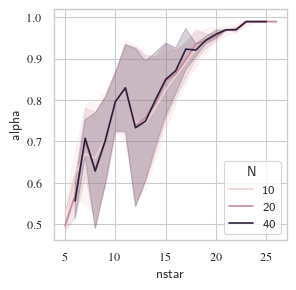

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(3, 3))

sns.lineplot(data=df_nstar, x="nstar", y="alpha", hue="N", ax=ax, errorbar="sd")
plt.show()

# Is $n^*$ any good?

Take the predicted $n^*$ and compute the external validity of studies of size $n^*$. Will it be above $\alpha$?

In [55]:
groupby_keys = ["na", "kernel", "N", "rep", "nstar", "disjoint", "replace"]

distr = du.UniformDistribution(na=8)
sample = distr.sample(2000)
kernel = Kernel.from_string(df_nstar["kernel"].values[0])
mmds = {}
for nstar in df_nstar["nstar"].unique():
    mmds[8, df_nstar["kernel"].values[0], nstar] = kernel.mmd_distribution(sample, n=nstar, rep=1000, disjoint=False, replace=True, method="embedding")

# this alpha should be below the actual external validity for any n (including nstar)
def alphamin(ktildeP, eps, n):
    return 1 - 2 * (1 - ktildeP) / (eps**2 * n)

Kxx = kernel.gram_matrix(sample)
ktildeP = np.mean(Kxx - np.diag(np.diag(Kxx)))

out = []
for group, tmp in df_nstar.groupby(groupby_keys):
    na = group[0]
    kernel_name = group[1]
    N = group[2]
    rep = group[3]
    nstar = group[4]
    disjoint = group[5]
    replace = group[6]
    # maximum alpha associated to an nstar (i.e., predicted external validity for an nstar)
    alpha = tmp["alpha"].max()
    eps = tmp["eps"].values[0]

    # true external validity is obtained by sampling with replacement from a large enough pool
    out.append({
        "N": N,
        "rep": rep,
        "validity": np.mean(mmds[na, kernel_name, nstar] <= eps),
        "alpha": alpha,
        "nstar": nstar,
        "disjoint": disjoint,
        "replace": replace,
        "alphamin": alphamin(ktildeP, eps, nstar),
    })

    # print("EMMD^2_n - formula: ", np.mean(mmds[na, kernel_name, nstar] ** 2) - 2/nstar * (1-ktildeP))

dfval = pd.DataFrame(out)



In [56]:
dfval

,N,rep,validity,alpha,nstar,disjoint,replace,alphamin
0,10,0,0.085,0.55,5,False,False,-0.581471
1,10,0,0.220,0.71,6,False,False,-0.317892
2,10,0,0.404,0.83,7,False,False,-0.129622
3,10,0,0.404,0.53,7,False,True,-0.129622
4,10,0,0.592,0.89,8,False,False,0.011581
...,...,...,...,...,...,...,...,...
5217,40,49,0.999,0.91,17,True,True,0.534861
5218,40,49,0.997,0.93,18,True,True,0.560703
5219,40,49,0.999,0.95,19,True,True,0.583823
5220,40,49,0.999,0.97,20,True,True,0.604632


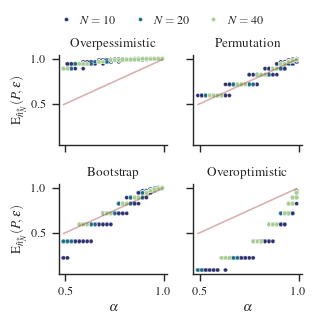

In [57]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import re
import seaborn as sns

mpl.rcParams['text.usetex'] = True                     # enable LaTeX
mpl.rcParams['text.latex.preamble'] = r"""
    \usepackage{mathptmx}
    \usepackage{amsmath}
    \usepackage{nicefrac}
"""
font = {
    "family": "Times New Roman",
    "size": 10
}
mpl.rc("font", **font)
sns.set(style="ticks", context="paper", font="serif")

boxplot_args = dict(
            showfliers=False,
            native_scale=False, fill=False, boxprops={"linewidth": 1.2},
        )

pretty_columns = dict(
    # alpha=r"$\hat\alpha_N$",
    alpha=r"$\alpha$",
    validity=r"$\text{E}_{\hat n^*_N}(P, \varepsilon)$",
    N=r"$N$",
)

# We want to know if the alpha associated to nstar is greater than the actual external validity
# alpha means that we predict that nstar results are enough to achieve alpha external validity, so, the actual external validity at nstar should be above alpha

fig, axes = plt.subplots(2, 2, figsize=(3.25, 3.25), sharex="all", sharey="all")
axes = axes.flatten()
i = 0
for disjoint, replace in product([True, False], repeat=2):
    ax = axes[i]

    dfplot = dfval.copy().query("disjoint == @disjoint and replace == @replace")
    dfplot.rename(columns=pretty_columns, inplace=True)

    axtitle = ""
    match disjoint, replace:
        case True, True:
            axtitle = "Overpessimistic"
        case True, False:
            axtitle = "Permutation"
        case False, True:
            axtitle = "Bootstrap"
        case False, False:
            axtitle = "Overoptimistic"
    ax.set_title(axtitle)

    # only the first panel draws a legend ("full": one entry per value of N); it is moved to the figure below
    sns.scatterplot(data=dfplot, x=dfplot[pretty_columns["alpha"]], y=dfplot[pretty_columns["validity"]],
                    hue=pretty_columns["N"], ax=ax, palette="crest_r", legend=False if i < 3 else True, s=8, linewidth=0.2)
    ax.plot(alphas, alphas, ls="-", c="maroon", alpha=0.3)

    sns.despine(top=True, right=True)

    i += 1

# one legend for the whole figure, on the right-hand side
# one legend for the whole figure, in a single row above the panels
handles, labels = ax.get_legend_handles_labels()
ax.get_legend().remove()
labels = [f"$N = {label}$" for label in labels]
plt.tight_layout(rect=(0, 0, 1, 0.94))  # leave the top of the figure for the legend
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=len(labels), frameon=False,
           handletextpad=0.1, columnspacing=1.0)
plt.savefig(figures_dir / "validity_vs_alphanstar_compplot.pdf")

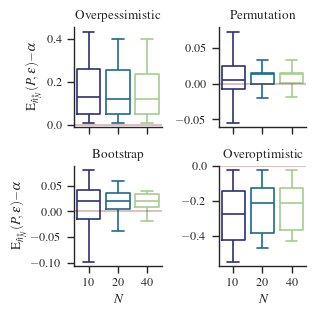

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(3.25, 3.25), sharex="all")
axes = axes.flatten()
i = 0
for disjoint, replace in product([True, False], repeat=2):
    ax = axes[i]
    axtitle = ""
    match disjoint, replace:
        case True, True:
            axtitle = "Overpessimistic"
        case True, False:
            axtitle = "Permutation"
        case False, True:
            axtitle = "Bootstrap"
        case False, False:
            axtitle = "Overoptimistic"
    ax.set_title(axtitle)

    dfplot = dfval.copy().query("disjoint == @disjoint and replace == @replace")
    dfplot.rename(columns=pretty_columns, inplace=True)

    diff_col = pretty_columns["validity"] + "$-$" + pretty_columns["alpha"]
    dfplot[diff_col] = dfplot[pretty_columns["validity"]] - dfplot[pretty_columns["alpha"]]
    sns.boxplot(data=dfplot, x=pretty_columns["N"], y=diff_col, ax=ax, **boxplot_args, hue=pretty_columns["N"], palette="crest_r", legend=False)
    ax.axhline(y=0, ls="-", c="maroon", alpha=0.3)

    sns.despine(top=True, right=True)

    if i % 2 == 1:
        ax.set_ylabel("")

    i += 1

plt.tight_layout()
plt.savefig(figures_dir / "validity_vs_alphanstar_boxplot.pdf")


Bootstrap plots

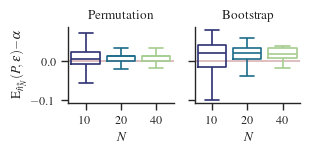

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(3.25, 1.625), sharey="all")
axes = axes.flatten()

i = 0
for disjoint, replace in [(True, False), (False, True)]:
    ax = axes[i]
    axtitle = ""
    match disjoint, replace:
        case True, True:
            axtitle = "Overpessimistic"
        case True, False:
            axtitle = "Permutation"
        case False, True:
            axtitle = "Bootstrap"
        case False, False:
            axtitle = "Overoptimistic"
    ax.set_title(axtitle)

    dfplot = dfval.copy().query("disjoint == @disjoint and replace == @replace")
    dfplot.rename(columns=pretty_columns, inplace=True)

    diff_col = pretty_columns["validity"] + "$-$" + pretty_columns["alpha"]
    dfplot[diff_col] = dfplot[pretty_columns["validity"]] - dfplot[pretty_columns["alpha"]]
    ax.axhline(y=0, ls="-", c="maroon", alpha=0.3)
    sns.boxplot(data=dfplot, x=pretty_columns["N"], y=diff_col, ax=ax, **boxplot_args, hue=pretty_columns["N"], palette="crest_r", legend=False)

    sns.despine(top=True, right=True)

    i += 1

plt.tight_layout()
plt.savefig(figures_dir / "validity_vs_alphanstar_boxplot_permutation_bootstrap.pdf")